# 06 — Final Test-Set Evaluation

**Brain Tumor Detection** — the honest final benchmark.

The held-out test set (1,600 images, 400 per class) has never been
seen by training, validation, or hyperparameter tuning. This notebook
evaluates every model + the ensemble on it for the first and only time.

Outputs:
* `outputs/confusion_matrices/{cnn,transfer,swin,ensemble}_test_cm.png`
* `outputs/plots/roc_curves_test.png`
* `outputs/plots/final_comparison_bars.png`
* `outputs/plots/efficiency_pareto.png`
* `outputs/reports/final_comparison.csv`
* `outputs/reports/per_class_metrics.csv`
* `outputs/reports/inference_benchmark.csv`

In [1]:
# --- 0. Setup ---------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.config       import CLASS_NAMES, NUM_CLASSES, BATCH_SIZE, NUM_WORKERS, OUTPUTS_DIR, MODELS_DIR
from src.data_loader  import get_dataloaders
from src.ensemble     import (
    collect_probs, weighted_average, soft_voting, accuracy,
    EnsembleConfig, load_all_models,
)
from src.evaluate     import (
    plot_confusion_matrix, build_classification_report, per_class_metrics_df,
    macro_roc_auc, per_class_auc, plot_multimodel_roc,
    benchmark_inference, total_training_seconds,
)
from src.utils        import get_device, set_seed

set_seed(42)
sns.set_theme(style='whitegrid', context='notebook')
device = get_device()
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce GTX 1650


## 1. Load all models + ensemble config

In [2]:
models = load_all_models(
    device,
    cnn_path      = MODELS_DIR / 'cnn_model.pth',
    transfer_path = MODELS_DIR / 'transfer_model.pth',
    swin_path     = MODELS_DIR / 'swin_model.pth',
)
ec = EnsembleConfig.load(MODELS_DIR / 'ensemble_config.json')
print(f'Ensemble method : {ec.method}')
print(f'Weights         : {ec.weights}')
for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  {name:9s}: {type(m).__name__:14s}  ({n_params:>12,} params)')

Ensemble method : weighted
Weights         : [0.0, 0.8999999761581421, 0.10000000149011612]
  cnn      : BrainTumorCNN   (   1,206,628 params)
  transfer : TransferModel   (   4,012,672 params)
  swin     : SwinModel       (  27,522,430 params)


## 2. Collect TEST probabilities from each model

*This is the first and only time we touch the test set.*

In [3]:
_, _, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)

probs_test = {}
labels_test = None
for name, m in models.items():
    p, y = collect_probs(m, test_loader, device, desc=f'{name} test')
    probs_test[name] = p
    if labels_test is None:
        labels_test = y
    else:
        assert np.array_equal(labels_test, y)
    print(f'  {name:9s} -> test_acc = {accuracy(p, y):.4f}, AUC = {macro_roc_auc(y, p):.4f}')

# Ensemble probabilities (using the winning weights from STEP 14)
prob_list = [probs_test['cnn'], probs_test['transfer'], probs_test['swin']]
if ec.method == 'weighted':
    probs_test['ensemble'] = weighted_average(prob_list, ec.weights)
elif ec.method == 'soft_voting':
    probs_test['ensemble'] = soft_voting(prob_list)
else:  # stacking would need to be re-fit on val; defaulting to weighted here
    probs_test['ensemble'] = weighted_average(prob_list, ec.weights or [1/3, 1/3, 1/3])

print(f"  ensemble  -> test_acc = {accuracy(probs_test['ensemble'], labels_test):.4f}, "
      f"AUC = {macro_roc_auc(labels_test, probs_test['ensemble']):.4f}")

cnn test:   0%|          | 0/50 [00:13<?, ?it/s]

  cnn       -> test_acc = 0.8275, AUC = 0.9513


transfer test:   0%|          | 0/50 [00:00<?, ?it/s]

  transfer  -> test_acc = 0.9494, AUC = 0.9908


swin test:   0%|          | 0/50 [00:00<?, ?it/s]

  swin      -> test_acc = 0.9194, AUC = 0.9865
  ensemble  -> test_acc = 0.9469, AUC = 0.9907


## 3. Per-model test confusion matrices

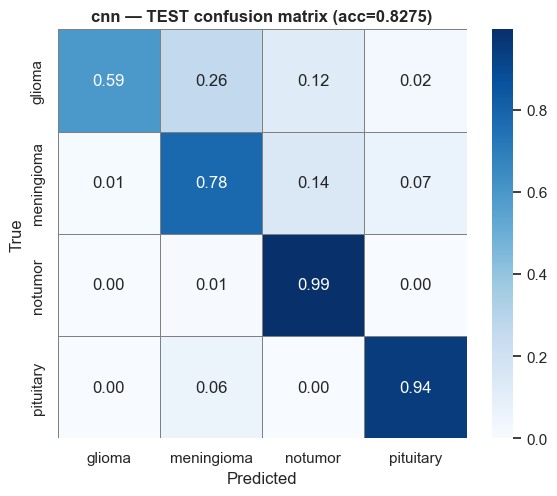

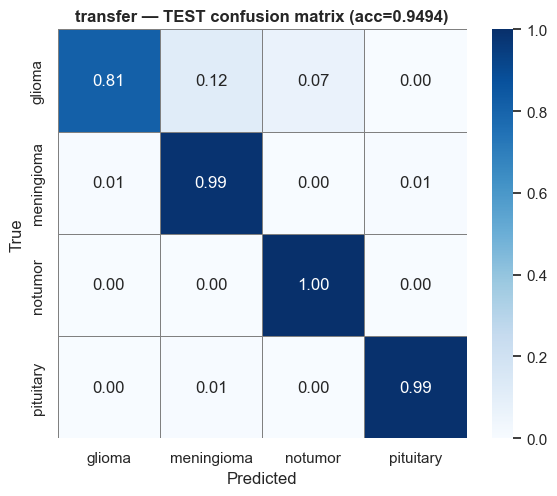

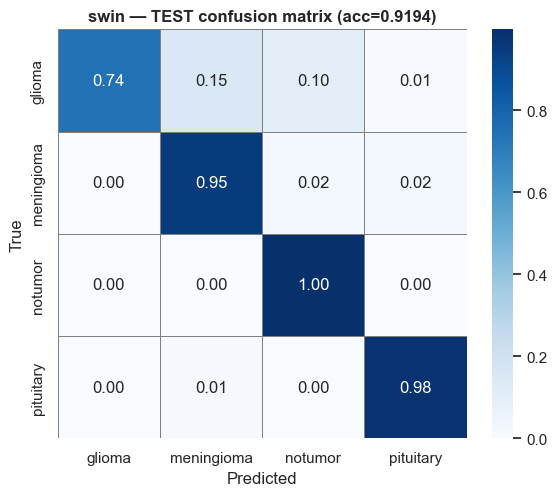

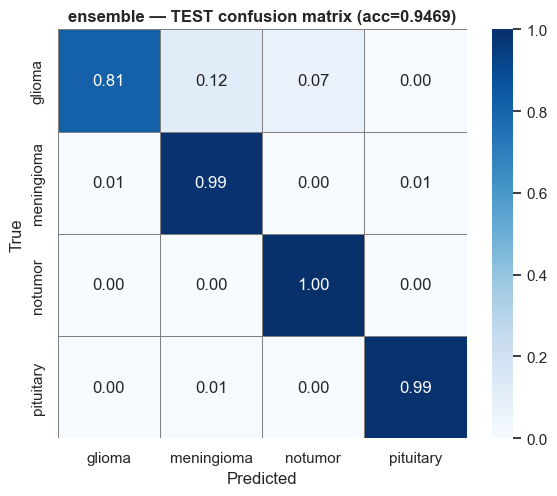

In [4]:
for name, probs in probs_test.items():
    y_pred = probs.argmax(axis=1)
    test_acc = accuracy(probs, labels_test)
    fig = plot_confusion_matrix(
        labels_test, y_pred, CLASS_NAMES, normalize=True,
        title=f'{name} — TEST confusion matrix (acc={test_acc:.4f})',
        save_path=OUTPUTS_DIR / 'confusion_matrices' / f'{name}_test_cm.png',
    )
    plt.show()

## 4. ROC curves (one-vs-rest), all models overlaid per class

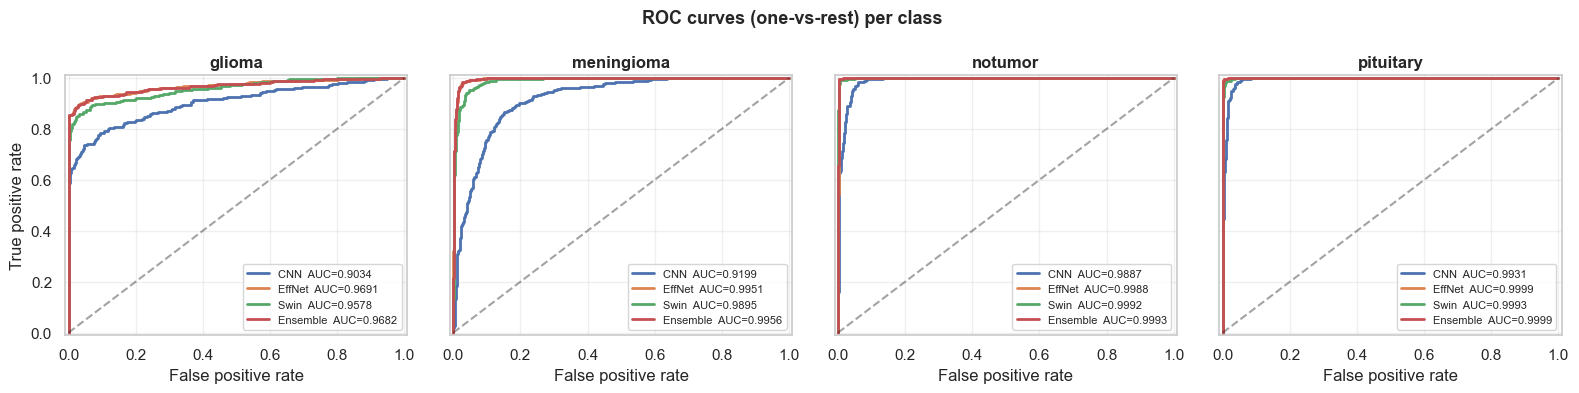

In [5]:
fig = plot_multimodel_roc(
    probs_dict={
        'CNN':      probs_test['cnn'],
        'EffNet':   probs_test['transfer'],
        'Swin':     probs_test['swin'],
        'Ensemble': probs_test['ensemble'],
    },
    y_true=labels_test,
    class_names=CLASS_NAMES,
    save_path=OUTPUTS_DIR / 'plots' / 'roc_curves_test.png',
)
plt.show()

## 5. Per-class metrics table

In [6]:
rows = []
for name, probs in probs_test.items():
    df = per_class_metrics_df(labels_test, probs.argmax(axis=1), CLASS_NAMES)
    auc = per_class_auc(labels_test, probs, CLASS_NAMES)
    df = df.merge(auc, on='class')
    df.insert(0, 'model', name)
    rows.append(df)

per_class = pd.concat(rows, ignore_index=True)
for c in ['precision', 'recall', 'f1', 'auc']:
    per_class[c] = per_class[c].round(4)

print(per_class.to_string(index=False))
per_class.to_csv(OUTPUTS_DIR / 'reports' / 'per_class_metrics.csv', index=False)

   model      class  precision  recall     f1  support    auc
     cnn     glioma     0.9834  0.5925 0.7395      400 0.9034
     cnn meningioma     0.7068  0.7775 0.7405      400 0.9199
     cnn    notumor     0.7881  0.9950 0.8796      400 0.9887
     cnn  pituitary     0.9130  0.9450 0.9287      400 0.9931
transfer     glioma     0.9939  0.8150 0.8956      400 0.9691
transfer meningioma     0.8916  0.9875 0.9371      400 0.9951
transfer    notumor     0.9346  1.0000 0.9662      400 0.9988
transfer  pituitary     0.9925  0.9950 0.9938      400 0.9999
    swin     glioma     0.9966  0.7425 0.8510      400 0.9578
    swin meningioma     0.8523  0.9525 0.8996      400 0.9895
    swin    notumor     0.8886  0.9975 0.9399      400 0.9992
    swin  pituitary     0.9704  0.9850 0.9777      400 0.9993
ensemble     glioma     0.9939  0.8100 0.8926      400 0.9682
ensemble meningioma     0.8876  0.9875 0.9349      400 0.9956
ensemble    notumor     0.9302  1.0000 0.9639      400 0.9993
ensemble

## 6. Inference-speed benchmark

Pure forward-pass latency (no data loading). Random inputs, 10 warmup
+ 50 timed iterations, GPU synchronized around each.

In [7]:
bench_rows = []
for name, m in models.items():
    for bs in (1, 32):
        r = benchmark_inference(m, device, batch_size=bs, n_warmup=10, n_iter=50,
                                use_amp=(device.type == 'cuda'),
                                amp_dtype=torch.bfloat16)
        r['model'] = name
        r['per_image_ms'] = r['mean_ms'] / bs
        bench_rows.append(r)
        print(f"  {name:9s} bs={bs:>2d}: {r['mean_ms']:7.2f} ms  "
              f"(per-image {r['per_image_ms']:6.2f} ms, throughput {r['throughput_imgs_per_sec']:7.1f} imgs/s)")

# Ensemble is sequential through all 3 models, so latency adds.
for bs in (1, 32):
    base = [r for r in bench_rows if r['batch_size'] == bs]
    mean_ms = sum(r['mean_ms'] for r in base)
    bench_rows.append({
        'model': 'ensemble',
        'batch_size': bs,
        'n_iter': base[0]['n_iter'],
        'mean_ms': mean_ms,
        'std_ms':  float(np.sqrt(sum(r['std_ms']**2 for r in base))),
        'p50_ms':  sum(r['p50_ms'] for r in base),
        'p95_ms':  sum(r['p95_ms'] for r in base),
        'throughput_imgs_per_sec': bs / (mean_ms / 1000.0),
        'per_image_ms': mean_ms / bs,
    })
    print(f"  ensemble  bs={bs:>2d}: {mean_ms:7.2f} ms  "
          f"(per-image {mean_ms/bs:6.2f} ms, throughput {bs/(mean_ms/1000):7.1f} imgs/s)")

bench_df = pd.DataFrame(bench_rows)
for c in ['mean_ms', 'std_ms', 'p50_ms', 'p95_ms', 'per_image_ms', 'throughput_imgs_per_sec']:
    bench_df[c] = bench_df[c].round(2)
bench_df.to_csv(OUTPUTS_DIR / 'reports' / 'inference_benchmark.csv', index=False)

  cnn       bs= 1:    6.79 ms  (per-image   6.79 ms, throughput   147.3 imgs/s)


  cnn       bs=32:  171.23 ms  (per-image   5.35 ms, throughput   186.9 imgs/s)


  transfer  bs= 1:   24.12 ms  (per-image  24.12 ms, throughput    41.5 imgs/s)


  transfer  bs=32:  108.18 ms  (per-image   3.38 ms, throughput   295.8 imgs/s)


  swin      bs= 1:   25.71 ms  (per-image  25.71 ms, throughput    38.9 imgs/s)


  swin      bs=32:  266.16 ms  (per-image   8.32 ms, throughput   120.2 imgs/s)
  ensemble  bs= 1:   56.62 ms  (per-image  56.62 ms, throughput    17.7 imgs/s)
  ensemble  bs=32:  545.57 ms  (per-image  17.05 ms, throughput    58.7 imgs/s)


## 7. Training time per model

In [8]:
train_sec = {
    'cnn':       total_training_seconds([OUTPUTS_DIR / 'reports' / 'cnn_history.json']),
    'transfer':  total_training_seconds([
                    OUTPUTS_DIR / 'reports' / 'transfer_stage1_history.json',
                    OUTPUTS_DIR / 'reports' / 'transfer_stage2_history.json',
                  ]),
    'swin':      total_training_seconds([
                    OUTPUTS_DIR / 'reports' / 'swin_stage1_history.json',
                    OUTPUTS_DIR / 'reports' / 'swin_stage2_history.json',
                  ]),
}
train_sec['ensemble'] = sum(v for k, v in train_sec.items() if k != 'ensemble')
for name, s in train_sec.items():
    print(f'  {name:9s} : {s/60:6.1f} min')

  cnn       :   32.1 min
  transfer  :   14.9 min
  swin      :   12.5 min
  ensemble  :   59.5 min


## 8. Final comparison table

In [ ]:
# Load val accuracies from earlier reports for the val-vs-test comparison.
ec_metrics = ec.metrics or {}
cnn_hist  = json.loads((OUTPUTS_DIR / 'reports' / 'cnn_history.json').read_text())
tl_s2     = json.loads((OUTPUTS_DIR / 'reports' / 'transfer_stage2_history.json').read_text())
sw_s2     = json.loads((OUTPUTS_DIR / 'reports' / 'swin_stage2_history.json').read_text())
val_acc_lookup = {
    'cnn':      max(cnn_hist['val_acc']),
    'transfer': max(tl_s2['val_acc']),
    'swin':     max(sw_s2['val_acc']),
    'ensemble': float(ec_metrics.get('val_acc', np.nan)),
}
param_lookup = {
    'cnn':      sum(p.numel() for p in models['cnn'].parameters()),
    'transfer': sum(p.numel() for p in models['transfer'].parameters()),
    'swin':     sum(p.numel() for p in models['swin'].parameters()),
    'ensemble': sum(sum(p.numel() for p in m.parameters()) for m in models.values()),
}

rows = []
for name in ['cnn', 'transfer', 'swin', 'ensemble']:
    pretty = {
        'cnn': 'Custom CNN', 'transfer': 'EfficientNet-B0',
        'swin': 'Swin-Tiny', 'ensemble': f'Ensemble ({ec.method})',
    }[name]
    p = probs_test[name]
    y_pred = p.argmax(axis=1)
    pc = per_class_metrics_df(labels_test, y_pred, CLASS_NAMES)
    pr, rc, f1 = pc[['precision', 'recall', 'f1']].mean().tolist()
    bs1 = next(r for r in bench_rows if r['model'] == name and r['batch_size'] == 1)
    rows.append({
        'Model':         pretty,
        'Params':        f"{param_lookup[name]:,}",
        'Val acc':       round(val_acc_lookup[name], 4),
        'Test acc':      round(accuracy(p, labels_test), 4),
        'Macro F1':      round(f1, 4),
        'Macro AUC':     round(macro_roc_auc(labels_test, p), 4),
        'Train min':     round(train_sec[name] / 60, 1),
        'Latency ms/img (bs=1)': round(bs1['per_image_ms'], 2),
    })

final_df = pd.DataFrame(rows)
print(final_df.to_string(index=False))
final_df.to_csv(OUTPUTS_DIR / 'reports' / 'final_comparison.csv', index=False)
print(f"\nSaved -> {OUTPUTS_DIR / 'reports' / 'final_comparison.csv'}")

              Model     Params  Val acc  Test acc  Macro F1  Macro AUC  Train min  Latency ms/img (bs=1)
         Custom CNN  1,206,628   0.9036    0.8275    0.8221     0.9513       32.1                   6.79
    EfficientNet-B0  4,012,672   0.9893    0.9494    0.9482     0.9908       14.9                  24.12
          Swin-Tiny 27,522,430   0.9670    0.9194    0.9171     0.9865       12.5                  25.71
Ensemble (weighted) 32,741,730   0.9893    0.9469    0.9456     0.9907       59.5                  56.62

Saved -> C:\Brain Tumor Detection\outputs\reports\final_comparison.csv


## 9. Final comparison plots

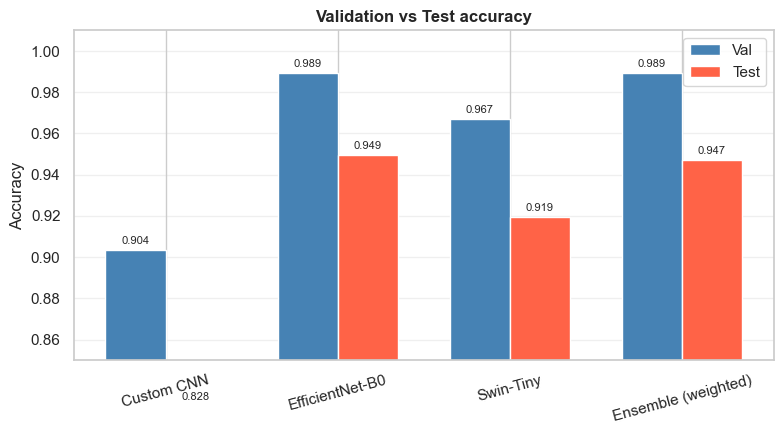

In [10]:
# 9a. Val vs Test accuracy bars
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(final_df))
width = 0.35
ax.bar(x - width/2, final_df['Val acc'],  width, color='steelblue', label='Val')
ax.bar(x + width/2, final_df['Test acc'], width, color='tomato',    label='Test')
for i, (v, t) in enumerate(zip(final_df['Val acc'], final_df['Test acc'])):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(final_df['Model'], rotation=15)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.85, 1.01)
ax.set_title('Validation vs Test accuracy', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'plots' / 'final_comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()

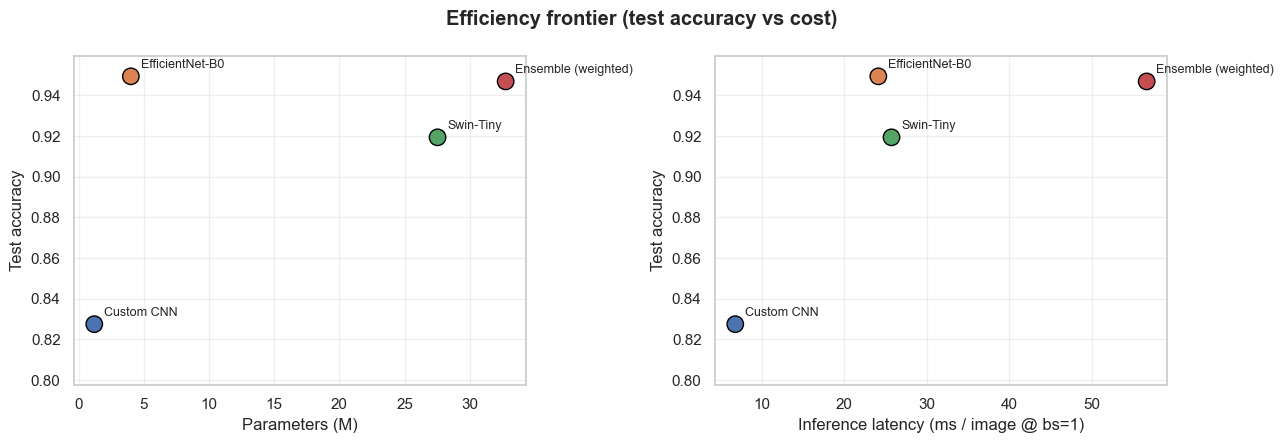

In [11]:
# 9b. Efficiency Pareto: params vs accuracy, latency vs accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

param_axis = [param_lookup[n] / 1e6 for n in ['cnn', 'transfer', 'swin', 'ensemble']]
lat_axis   = [next(r for r in bench_rows if r['model'] == n and r['batch_size'] == 1)['per_image_ms']
              for n in ['cnn', 'transfer', 'swin', 'ensemble']]
acc_axis   = final_df['Test acc'].tolist()
labels     = final_df['Model'].tolist()

for ax, x_data, x_label in [(axes[0], param_axis, 'Parameters (M)'),
                            (axes[1], lat_axis,   'Inference latency (ms / image @ bs=1)')]:
    ax.scatter(x_data, acc_axis, s=140, c=['#4C72B0', '#DD8452', '#55A467', '#C44E52'],
               edgecolor='black', linewidth=1, zorder=3)
    for x, y, lbl in zip(x_data, acc_axis, labels):
        ax.annotate(lbl, (x, y), xytext=(7, 6), textcoords='offset points', fontsize=9)
    ax.set_xlabel(x_label); ax.set_ylabel('Test accuracy')
    ax.grid(alpha=0.3); ax.set_ylim(min(acc_axis) - 0.03, max(acc_axis) + 0.01)

fig.suptitle('Efficiency frontier (test accuracy vs cost)', fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'plots' / 'efficiency_pareto.png', dpi=120, bbox_inches='tight')
plt.show()

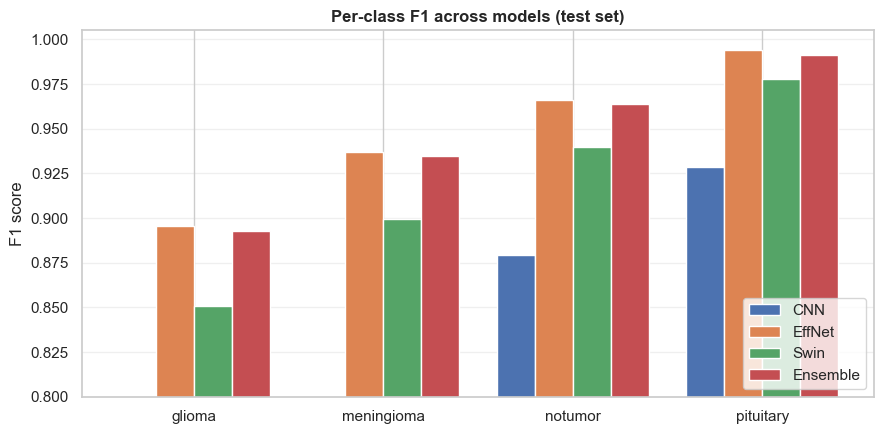

In [12]:
# 9c. Per-class F1 across models (groupwise bars)
fig, ax = plt.subplots(figsize=(9, 4.5))
models_order = ['cnn', 'transfer', 'swin', 'ensemble']
pretty       = ['CNN', 'EffNet', 'Swin', 'Ensemble']
x = np.arange(len(CLASS_NAMES))
w = 0.2
colors = ['#4C72B0', '#DD8452', '#55A467', '#C44E52']

for i, m in enumerate(models_order):
    f1_per_cls = per_class[per_class['model'] == m].set_index('class').reindex(CLASS_NAMES)['f1'].values
    ax.bar(x + (i - 1.5) * w, f1_per_cls, w, label=pretty[i], color=colors[i])

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0.80, 1.005); ax.set_ylabel('F1 score')
ax.set_title('Per-class F1 across models (test set)', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'plots' / 'per_class_f1_bars.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Summary

Artifacts:
* `outputs/reports/final_comparison.csv`              — the headline table for the report
* `outputs/reports/per_class_metrics.csv`             — precision/recall/F1/AUC per (model, class)
* `outputs/reports/inference_benchmark.csv`           — latency + throughput at bs=1 and bs=32
* `outputs/plots/roc_curves_test.png`                 — OvR ROC, all 4 models
* `outputs/plots/final_comparison_bars.png`           — val vs test bars
* `outputs/plots/efficiency_pareto.png`               — accuracy vs cost
* `outputs/plots/per_class_f1_bars.png`               — per-class F1 across models
* `outputs/confusion_matrices/{name}_test_cm.png`     — one per model

**Next:** STEP 16 — explainability (Grad-CAM for CNN/EffNet, attention rollout for Swin).